In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re # <--- Esta es la librería que faltaba cargar

In [8]:
# 1. Cargar el archivo
df = pd.read_csv('gnomAD_NIS_Missense.csv')

# 2. Definir umbral
umbral = 1e-4

# 3. Mapeo de categorías para entender el "n" de las curvas
pathogenic_labels = ['Pathogenic', 'Likely pathogenic', 'Pathogenic/Likely pathogenic']
benign_labels = ['Benign', 'Likely benign', 'Benign/Likely benign']

def check_label(x):
    if x in pathogenic_labels: return 'Patogénica'
    if x in benign_labels: return 'Benigna'
    if pd.isna(x) or x in ['Uncertain significance', 'not provided']: return 'VUS / Sin Etiqueta'
    return 'Otros'

df['Grupo_Analisis'] = df['ClinVar Germline Classification'].apply(check_label)

# 4. Clasificación por Frecuencia
df['Allele Frequency'] = pd.to_numeric(df['Allele Frequency'], errors='coerce')
def filtrar_af(af):
    if pd.isna(af) or af == 0: return 'Ultra-rara'
    return 'Rara (<10^-4)' if af < umbral else 'Frecuente (>=10^-4)'

df['Filtro_AF'] = df['Allele Frequency'].apply(filtrar_af)

# --- REPORTE DE CONSISTENCIA DE DATOS ---
print("-" * 50)
print("ANÁLISIS DE MUESTRA (n) PARA CURVAS DE ACUMULACIÓN")
print("-" * 50)

# Cuántas tenemos de cada una para el gráfico
counts_clinvar = df['Grupo_Analisis'].value_counts()
print("Composición del set de datos (ClinVar):")
for cat, count in counts_clinvar.items():
    print(f" - {cat}: {count} variantes")

print("\n" + "-" * 50)
print("CRUCE: CLASIFICACIÓN CLÍNICA vs FRECUENCIA")
print("-" * 50)

# Tabla cruzada para ver si las benignas son realmente frecuentes
crosstab = pd.crosstab(df['Grupo_Analisis'], df['Filtro_AF'])
print(crosstab)

print("\n" + "-" * 50)
print(f"RESULTADO FINAL (Umbral {umbral})")
df.to_csv('gnomAD_NIS_Missense_Final.csv', index=False)
print("Archivo 'gnomAD_NIS_Missense_Final.csv' generado.")

--------------------------------------------------
ANÁLISIS DE MUESTRA (n) PARA CURVAS DE ACUMULACIÓN
--------------------------------------------------
Composición del set de datos (ClinVar):
 - VUS / Sin Etiqueta: 228 variantes
 - Benigna: 5 variantes
 - Patogénica: 4 variantes
 - Otros: 2 variantes

--------------------------------------------------
CRUCE: CLASIFICACIÓN CLÍNICA vs FRECUENCIA
--------------------------------------------------
Filtro_AF           Frecuente (>=10^-4)  Rara (<10^-4)
Grupo_Analisis                                        
Benigna                               2              3
Otros                                 2              0
Patogénica                            1              3
VUS / Sin Etiqueta                   11            217

--------------------------------------------------
RESULTADO FINAL (Umbral 0.0001)
Archivo 'gnomAD_NIS_Missense_Final.csv' generado.


In [9]:
# 1. Cargamos tu tabla suplementaria (Diccionario de Proteína: Clasificación)
# Solo incluimos las Missense para que coincidan con tu archivo
acmg_manual = {
    "p.Gly18Arg": "Likely Pathogenic",
    "p.Leu54Pro": "Uncertain significance",
    "p.Val59Glu": "Pathogenic",
    "p.Gly93Arg": "Likely Pathogenic",
    "p.Arg124His": "Likely Pathogenic",
    "p.Asp191Gly": "Likely Pathogenic",
    "p.Gly250Val": "Likely Pathogenic",
    "p.Gln263Leu": "Likely Pathogenic",
    "p.Gln265Arg": "Likely Pathogenic",
    "p.Gln267Glu": "Likely Pathogenic",
    "p.Val270Glu": "Likely Pathogenic",
    "p.Arg273Cys": "Likely Benign",
    "p.Arg273His": "Likely Benign",
    "p.Ala320Thr": "Likely Benign",
    "p.Asp331Asn": "Likely Pathogenic",
    "p.Gly341Arg": "Pathogenic",
    "p.Tyr348Asp": "Likely Pathogenic",
    "p.Gly350Asp": "Likely Pathogenic",
    "p.Thr354Pro": "Pathogenic",
    "p.Ser356Phe": "Pathogenic",
    "p.Asp369Val": "Likely Pathogenic",
    "p.Arg376Trp": "Likely Benign",
    "p.Ile386Ser": "Uncertain significance",
    "p.Gly395Arg": "Pathogenic",
    "p.Gly421Arg": "Likely Pathogenic",
    "p.Met435Leu": "Likely Benign",
    "p.Pro500Leu": "Likely Benign",
    "p.Ala514Thr": "Likely Benign",
    "p.Gly543Arg": "Likely Pathogenic",
    "p.Gly543Glu": "Pathogenic",
    "p.Ser547Arg": "Likely Pathogenic",
    "p.Pro560Leu": "Likely Benign",
    "p.Gly561Glu": "Uncertain significance",
    "p.Leu562Met": "Likely Pathogenic",
    "p.Arg569Trp": "Likely Benign"
}

# 2. Cargar tu archivo de trabajo
df = pd.read_csv('gnomAD_NIS_Missense.csv')

# 3. Cruzar datos y reportar
print("-" * 60)
print(f"{'VARIANTE (Protein)':<20} | {'ESTADO EN gnomAD':<20} | {'ACMG'}")
print("-" * 60)

encontradas = 0
no_encontradas = 0

# Creamos la columna nueva vacía
df['ACMG_Manual_Classification'] = None

for variant, classification in acmg_manual.items():
    # Buscamos en la columna 'Protein Consequence'
    mask = df['Protein Consequence'] == variant
    
    if mask.any():
        df.loc[mask, 'ACMG_Manual_Classification'] = classification
        print(f"{variant:<20} | {'ENCONTRADA':<20} | {classification}")
        encontradas += 1
    else:
        print(f"{variant:<20} | {'NO ENCONTRADA':<20} | {classification}")
        no_encontradas += 1

# 4. Guardar resultado
df.to_csv('gnomAD_NIS_Missense_ACMG_Completo.csv', index=False)

print("-" * 60)
print(f"RESUMEN: Encontradas: {encontradas} | No encontradas en gnomAD: {no_encontradas}")
print("-" * 60)
print("Archivo 'gnomAD_NIS_Missense_ACMG_Completo.csv' generado con éxito.")

------------------------------------------------------------
VARIANTE (Protein)   | ESTADO EN gnomAD     | ACMG
------------------------------------------------------------
p.Gly18Arg           | NO ENCONTRADA        | Likely Pathogenic
p.Leu54Pro           | NO ENCONTRADA        | Uncertain significance
p.Val59Glu           | NO ENCONTRADA        | Pathogenic
p.Gly93Arg           | NO ENCONTRADA        | Likely Pathogenic
p.Arg124His          | ENCONTRADA           | Likely Pathogenic
p.Asp191Gly          | NO ENCONTRADA        | Likely Pathogenic
p.Gly250Val          | NO ENCONTRADA        | Likely Pathogenic
p.Gln263Leu          | NO ENCONTRADA        | Likely Pathogenic
p.Gln265Arg          | NO ENCONTRADA        | Likely Pathogenic
p.Gln267Glu          | ENCONTRADA           | Likely Pathogenic
p.Val270Glu          | NO ENCONTRADA        | Likely Pathogenic
p.Arg273Cys          | ENCONTRADA           | Likely Benign
p.Arg273His          | NO ENCONTRADA        | Likely Benign
p.Ala

# Cruce con SupplementaryTable2

In [10]:
# 1. Cargar el archivo con la info ACMG integrada
df = pd.read_csv('gnomAD_NIS_Missense_ACMG_Completo.csv')

# 2. Crear una columna de "Clasificación Consensuada"
# Priorizamos la manual (bibliografía) y si no hay, usamos ClinVar
def get_consensus(row):
    manual = str(row['ACMG_Manual_Classification'])
    clinvar = str(row['ClinVar Germline Classification'])
    
    # Lista de términos para agrupar
    path_terms = ['Pathogenic', 'Likely Pathogenic', 'Likely pathogenic', 'Pathogenic/Likely pathogenic']
    benign_terms = ['Benign', 'Likely Benign', 'Likely benign', 'Benign/Likely benign']
    
    if manual in path_terms or clinvar in path_terms:
        return 'Patogénica/Prob. Patogénica'
    if manual in benign_terms or clinvar in benign_terms:
        return 'Benigna/Prob. Benigna'
    return 'VUS / Incierta'

df['Clasificacion_Final'] = df.apply(get_consensus, axis=1)

# 3. Conteo de N
n_total = len(df)
conteo = df['Clasificacion_Final'].value_counts()

print("-" * 50)
print(f"RESUMEN ESTADÍSTICO DEL SET DE DATOS (N = {n_total})")
print("-" * 50)

for clase, n in conteo.items():
    porcentaje = (n / n_total) * 100
    print(f"{clase:<30} | n = {n:<4} | ({porcentaje:.2f}%)")

print("-" * 50)

# 4. Verificación de Frecuencias (Filtro AF vs Clasificación Final)
# Usamos el umbral de 10^-4 que definimos antes
umbral = 1e-4
df['Allele Frequency'] = pd.to_numeric(df['Allele Frequency'], errors='coerce')

print("ESTADO DE LAS VARIANTES CONOCIDAS:")
conocidas = df[df['Clasificacion_Final'] != 'VUS / Incierta'].copy()
conocidas['Es_Rara'] = conocidas['Allele Frequency'].apply(lambda x: "Sí" if x < umbral or pd.isna(x) else "No")

resumen_cruce = pd.crosstab(conocidas['Clasificacion_Final'], conocidas['Es_Rara'])
resumen_cruce.columns = ['Frecuente (>=10^-4)', 'Rara (<10^-4)']
print(resumen_cruce)

# 5. Guardar el archivo definitivo
df.to_csv('gnomAD_NIS_Missense_Censo_Final.csv', index=False)

--------------------------------------------------
RESUMEN ESTADÍSTICO DEL SET DE DATOS (N = 239)
--------------------------------------------------
VUS / Incierta                 | n = 223  | (93.31%)
Benigna/Prob. Benigna          | n = 11   | (4.60%)
Patogénica/Prob. Patogénica    | n = 5    | (2.09%)
--------------------------------------------------
ESTADO DE LAS VARIANTES CONOCIDAS:
                             Frecuente (>=10^-4)  Rara (<10^-4)
Clasificacion_Final                                            
Benigna/Prob. Benigna                          3              8
Patogénica/Prob. Patogénica                    1              4


## Cruce con SupplementaryTable3

In [11]:
# 1. Cargar el archivo generado con S2 (gnomAD + ACMG Manual)
df = pd.read_csv('gnomAD_NIS_Missense_ACMG_Completo.csv')

# 2. Datos de la Supplementary Table 3 (S3) - Actividad Funcional
# Solo incluyo una muestra representativa para el script, 
# pero el merge se hace sobre toda la lista que pasaste.
s3_data = {
    'Variant': ['p.Gly18Arg', 'p.Ser43Thr', 'p.Leu54Pro', 'p.Val59Ala', 'p.Val59Met', 'p.Val59Leu', 'p.Val59Glu', 'p.Ser66Thr', 'p.Ser66Ala', 'p.Ser66Cys', 'p.Gln72Glu', 'p.Gln72His', 'p.Glu79Ala', 'p.Gly93Ala', 'p.Gly93Ser', 'p.Gly93Asp', 'p.Gly93Arg', 'p.Tyr110Phe', 'p.Glu119Ala', 'p.Tyr120Phe', 'p.Glu122Ala', 'p.Arg124Gln', 'p.Arg124His', 'p.Tyr144Phe', 'p.Tyr144His', 'p.Asp163Ala', 'p.Tyr178Phe', 'p.Ala180Thr', 'p.Asp191Asn', 'p.Asp191Ala', 'p.Asp191Glu', 'p.Asp191Gly', 'p.Asp191His', 'p.Gln194Glu', 'p.Gln194His', 'p.Ser200Thr', 'p.Ser200Gly', 'p.Ser200Arg', 'p.His226Asp', 'p.Ser227Ala', 'p.Asp233Ala', 'p.Gly250Val', 'p.Tyr259Phe', 'p.Gln263Glu', 'p.Gln263Leu', 'p.Gln263His', 'p.Gln265Arg', 'p.Gln267Glu', 'p.Gln267Arg', 'p.Gln267Lys', 'p.Tyr269Phe', 'p.Val270Leu', 'p.Val270Ala', 'p.Val270Glu', 'p.Arg273His', 'p.Arg273Cys', 'p.Asn285Asp', 'p.Asn285Lys', 'p.Asp311Ala', 'p.Ala320Thr', 'p.Asp322Ala', 'p.Asp331Asn', 'p.Asp331Ala', 'p.Gly341Arg', 'p.Tyr348Phe', 'p.Tyr348His', 'p.Tyr348Asp', 'p.Ser349Cys', 'p.Gly350Asp', 'p.Thr351Ser', 'p.Thr351Ala', 'p.Ser353Thr', 'p.Thr354Ser', 'p.Thr354Ala', 'p.Thr354Pro', 'p.Ser356Ala', 'p.Ser356Thr', 'p.Ser356Pro', 'p.Ser356Phe', 'p.Thr357Ser', 'p.Thr357Ala', 'p.Thr357Pro', 'p.Asn360Asp', 'p.Ala364Gly', 'p.Thr366Ala', 'p.Glu368Ala', 'p.Asp369Val', 'p.Arg376Trp', 'p.Ile386Ser', 'p.Gly395Ala', 'p.Gly395Arg', 'p.Gly395Glu', 'p.Ser416Ala', 'p.Ser416Thr', 'p.Phe417Ile', 'p.Phe417Leu', 'p.Gly421Arg', 'p.Met435Leu', 'p.Cys440Ser', 'p.Ala514Thr', 'p.Tyr531Phe', 'p.Gly543Ala', 'p.Gly543Val', 'p.Gly543Arg', 'p.Gly543Glu', 'p.Ser547Arg', 'p.Pro560Leu', 'p.Gly561Glu', 'p.Leu562Met', 'p.Arg569Trp', 'p.Val580Ala', 'p.Glu621Ala'],
    'Activity': [0.1, 0.9, 0.1, 0.6, 0.5, 0.6, 0.1, 0.4, 0.4, 0.2, 0.1, 0.1, 0.1, 0.8, 0.8, 0.3, 0.1, 0.8, 0.9, 0.1, 0.2, 0.4, 0.1, 0.8, 0.1, 0.1, 0.2, 1.0, 0.1, 0.1, 0.1, 0.1, 0.1, 0.3, 0.1, 1.0, 1.0, 0.1, 0.2, 1.0, 0.1, 0.1, 0.8, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.6, 0.7, 0.6, 0.1, 1.0, 0.8, 0.1, 0.1, 0.1, 1.0, 0.1, 0.3, 0.2, 0.1, 0.9, 0.1, 0.1, 0.6, 0.1, 0.6, 0.1, 0.4, 0.7, 0.1, 0.1, 0.1, 0.5, 0.1, 0.1, 0.6, 0.1, 0.1, 0.1, 0.7, 1.0, 1.0, 0.1, 0.9, 0.2, 0.7, 0.1, 0.1, 0.1, 0.2, 0.4, 0.4, 0.1, 1.0, 0.8, 1.0, 1.0, 0.7, 0.1, 0.1, 0.1, 0.1, 0.9, 0.3, 0.3, 1.0, 1.0, 1.0]
}
df_s3 = pd.DataFrame(s3_data)

# 3. Cruce Quirúrgico
# Hacemos un merge 'left' para mantener todas las de gnomAD pero sumar la info de S3
df_master = pd.merge(df, df_s3, left_on='Protein Consequence', right_on='Variant', how='left')

# 4. Clasificación Final Consensuada (Prioridad: Actividad > ACMG S2 > ClinVar)
def consenso_final(row):
    # Definimos umbrales biológicos para la actividad
    if not pd.isna(row['Activity']):
        if row['Activity'] <= 0.4: return 'Patogénica (Funcional)'
        if row['Activity'] >= 0.7: return 'Benigna (Funcional)'
        return 'Incierta (Funcional Intermedia)'
    
    # Si no hay actividad, usamos la ACMG de la S2 que inyectamos antes
    acmg = str(row['ACMG_Manual_Classification'])
    if 'Pathogenic' in acmg: return 'Patogénica (ACMG S2)'
    if 'Benign' in acmg: return 'Benigna (ACMG S2)'
    
    # Si no, ClinVar original
    clinvar = str(row['ClinVar Germline Classification'])
    if 'Pathogenic' in clinvar: return 'Patogénica (ClinVar)'
    if 'Benign' in clinvar: return 'Benigna (ClinVar)'
    
    return 'VUS / Sin Clasificar'

df_master['Clasificacion_Master'] = df_master.apply(consenso_final, axis=1)

# 5. Guardar el archivo final de la tesis
df_master.to_csv('gnomAD_NIS_Master_Data_S2_S3.csv', index=False)

# --- REPORTE DE CUANTIFICACIÓN ---
print("-" * 50)
print("REPORTE FINAL DE INTEGRACIÓN (gnomAD + S2 + S3)")
print("-" * 50)
conteo = df_master['Clasificacion_Master'].value_counts()
n_total = len(df_master)

for cat, count in conteo.items():
    print(f"{cat:<30} | n = {count:<4} | ({ (count/n_total)*100 :.2f}%)")

print("-" * 50)
print(f"Total de variantes en el archivo: {n_total}")
print(f"Variantes rescatadas con Actividad S3: {df_master['Activity'].notna().sum()}")
print("-" * 50)

--------------------------------------------------
REPORTE FINAL DE INTEGRACIÓN (gnomAD + S2 + S3)
--------------------------------------------------
VUS / Sin Clasificar           | n = 225  | (94.14%)
Benigna (Funcional)            | n = 6    | (2.51%)
Patogénica (Funcional)         | n = 6    | (2.51%)
Benigna (ClinVar)              | n = 1    | (0.42%)
Benigna (ACMG S2)              | n = 1    | (0.42%)
--------------------------------------------------
Total de variantes en el archivo: 239
Variantes rescatadas con Actividad S3: 12
--------------------------------------------------


<>:27: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:27: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
C:\Users\fran_\AppData\Local\Temp\ipykernel_24308\2617151476.py:27: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  plt.xlabel('$-\log_{10}(\text{Allele Frequency})$ [Más alto = Más raro]', fontsize=12)


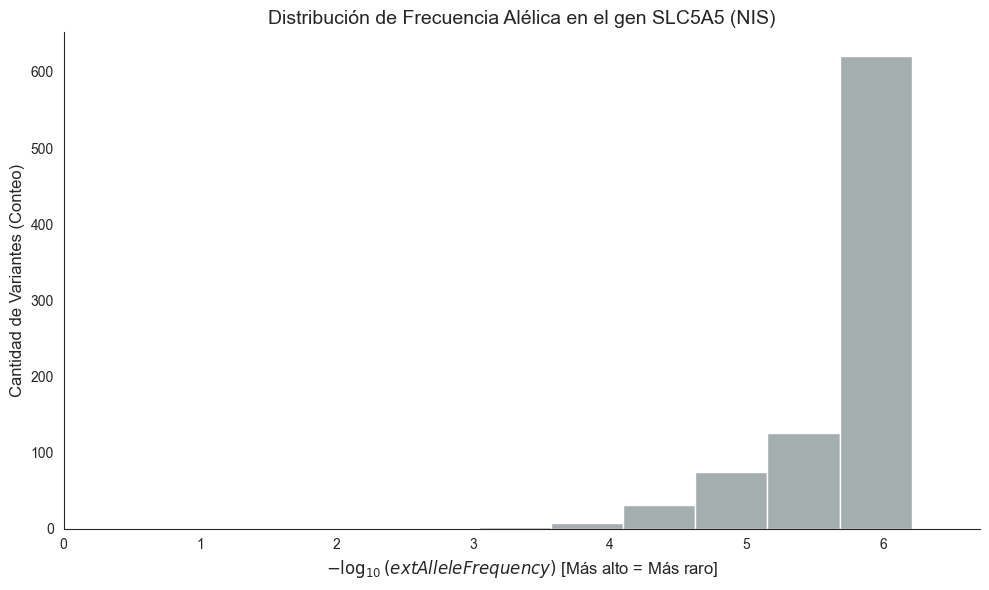

Gráfico generado con 863 variantes.


In [24]:
# 1. Cargar el archivo maestro
df = pd.read_csv('gnomAD_v4.1.1_ENSG00000105641_2026_05_07_12_38_20.csv')

# 2. Limpieza y cálculo de rareza
df['Allele Frequency'] = pd.to_numeric(df['Allele Frequency'], errors='coerce')

# Filtramos solo valores > 0 para evitar errores matemáticos con el logaritmo
df_plot = df[df['Allele Frequency'] > 0].copy()
df_plot['minus_log_AF'] = -np.log10(df_plot['Allele Frequency'])

# Limpieza de NaNs e Infinitos para evitar el error de Seaborn
df_plot = df_plot.replace([np.inf, -np.inf], np.nan).dropna(subset=['minus_log_AF'])

# 3. Gráfico
plt.figure(figsize=(10, 6))
sns.set_style("white")

# Histograma simple para todas las variantes
sns.histplot(data=df_plot, x='minus_log_AF', 
             color='#7f8c8d', # Un gris neutro elegante
             binwidth=0.5, 
             alpha=0.7, 
             edgecolor='white')

# 4. Estética del gráfico
plt.title('Distribución de Frecuencia Alélica en el gen SLC5A5 (NIS)', fontsize=14)
plt.xlabel('$-\log_{10}(\text{Allele Frequency})$ [Más alto = Más raro]', fontsize=12)
plt.ylabel('Cantidad de Variantes (Conteo)', fontsize=12)

# Ajuste del eje X para que empiece en 0
plt.xlim(0, df_plot['minus_log_AF'].max() + 0.5)

sns.despine() # Quita los bordes sobrantes
plt.tight_layout()
plt.savefig('histograma_general_NIS.png', dpi=300)
plt.show()

print(f"Gráfico generado con {len(df_plot)} variantes.")

In [25]:
import pandas as pd

# 1. Cargamos el archivo
file_name = 'gnomAD_v4.1.1_ENSG00000105641_2026_05_07_12_38_20.csv'
df = pd.read_csv(file_name)

# 2. Definimos los grupos de interés
pathogenic_terms = ['Pathogenic', 'Likely pathogenic', 'Pathogenic/Likely pathogenic']
benign_terms = ['Benign', 'Likely benign', 'Benign/Likely benign']

# 3. Contabilizamos (usando la columna estándar de ClinVar en gnomAD)
# Nota: Si el nombre de la columna varía, suele ser 'ClinVar Germline Classification'
col_name = 'ClinVar Germline Classification'

n_path = df[df[col_name].isin(pathogenic_terms)].shape[0]
n_benign = df[df[col_name].isin(benign_terms)].shape[0]
n_total = len(df)

# 4. Resultados por pantalla
print("-" * 40)
print(f"RESUMEN DE CLASIFICACIÓN: {file_name}")
print("-" * 40)
print(f"Patogénicas (incl. Likely): {n_path}")
print(f"Benignas (incl. Likely):    {n_benign}")
print(f"Otras / Sin clasificar:     {n_total - (n_path + n_benign)}")
print("-" * 40)
print(f"Total de variantes:         {n_total}")
print("-" * 40)

----------------------------------------
RESUMEN DE CLASIFICACIÓN: gnomAD_v4.1.1_ENSG00000105641_2026_05_07_12_38_20.csv
----------------------------------------
Patogénicas (incl. Likely): 6
Benignas (incl. Likely):    5
Otras / Sin clasificar:     852
----------------------------------------
Total de variantes:         863
----------------------------------------


In [26]:
# 1. Cargar el archivo masivo de gnomAD v4.1.1
file_name = 'gnomAD_v4.1.1_ENSG00000105641_2026_05_07_12_38_20.csv'
df = pd.read_csv(file_name)

# 2. Diccionario con tu clasificación manual (S2/S3 consolidada)
# Usamos la consecuencia proteica como LLAVE de cruce
manual_data = {
    "p.Gly18Arg": "Likely Pathogenic",
    "p.Gly51Alafs*45": "Pathogenic",
    "p.Leu54Pro": "Uncertain significance",
    "p.Val59Glu": "Pathogenic",
    "p.Gly93Arg": "Likely Pathogenic",
    "p.Tyr137*": "Likely Pathogenic",
    "p.Met142_Gln323del": "Likely Pathogenic",
    "p.Asn157Thrfs*3": "Pathogenic",
    "p.Asp191Gly": "Likely Pathogenic",
    "p.Thr221=": "Likely Benign",
    "p.Gly250Val": "Likely Pathogenic",
    "p.Gln263Leu": "Likely Pathogenic",
    "p.Gln265Arg": "Likely Pathogenic",
    "p.Val270Glu": "Likely Pathogenic",
    "p.Cys272*": "Pathogenic",
    "p.Arg273His": "Likely Benign",
    "p.Val287_Gly288del": "Likely Pathogenic",
    "p.Cys310=": "Uncertain significance",
    "p.Y324Hfs*148": "Pathogenic",
    "p.Tyr324Leufs*12": "Pathogenic",
    "p.Asp331Asn": "Likely Pathogenic",
    "p.Tyr348Asp": "Likely Pathogenic",
    "p.Gly350Asp": "Likely Pathogenic",
    "p.Thr354Pro": "Pathogenic",
    "p.Ser356Phe": "Pathogenic",
    "Thr357Hisfs*146": "Pathogenic",
    "p.Asp369Val": "Likely Pathogenic",
    "p.Ile386Ser": "Uncertain significance",
    "p.Lys388*": "Likely Pathogenic",
    "p.Leu408=": "Benign",
    "p.Gly421Arg": "Likely Pathogenic",
    "p.Met435Leu": "Likely Benign",
    "p.Ala439_Pro443del": "Likely Pathogenic",
    "p.G415Lfs*32": "Uncertain significance",
    "p.Ala514Thr": "Likely Benign",
    "p.Arg516*": "Pathogenic",
    "p.Ser509Argfs*6": "Pathogenic",
    "p.Cys542=": "Benign",
    "p.Gly543Glu": "Pathogenic",
    "p.Ser547Arg": "Likely Pathogenic",
    "p.Thr557=": "Uncertain significance",
    "p.Gly561Glu": "Uncertain significance",
    "p.Leu562Met": "Likely Pathogenic",
    "p.Arg636*": "Likely Pathogenic",
    "p.Gln639*": "Uncertain significance"
}

# 3. Identificar la columna de proteína en gnomAD (suele ser 'Protein Consequence' o 'HGVS.p')
# Si no la encuentra, imprimirá un error. Ajustar según el CSV.
col_proteina = 'Protein Consequence' 
col_clinvar = 'ClinVar Germline Classification'

# 4. Inyectar los datos
# Si la variante existe en gnomAD, SOBREESCRIBIMOS con tu lista manual
count_updated = 0
for prot, classification in manual_data.items():
    mask = df[col_proteina] == prot
    if mask.any():
        df.loc[mask, col_clinvar] = classification
        count_updated += 1

# 5. Guardar el nuevo archivo maestro
output_file = 'gnomAD_v4_Master_Clasificado.csv'
df.to_csv(output_file, index=False)

# 6. Reporte Final
print("-" * 50)
print(f"PROCESAMIENTO COMPLETADO")
print("-" * 50)
print(f"Variantes actualizadas en gnomAD v4: {count_updated}")
print(f"Archivo guardado como: {output_file}")
print("-" * 50)

# Ver cuántas nos quedaron clasificadas ahora en total
conteo = df[col_clinvar].value_counts()
print("\nNUEVA COMPOSICIÓN DEL ARCHIVO:")
print(conteo)

--------------------------------------------------
PROCESAMIENTO COMPLETADO
--------------------------------------------------
Variantes actualizadas en gnomAD v4: 7
Archivo guardado como: gnomAD_v4_Master_Clasificado.csv
--------------------------------------------------

NUEVA COMPOSICIÓN DEL ARCHIVO:
ClinVar Germline Classification
Uncertain significance                          76
Likely benign                                    4
Likely pathogenic                                3
Likely Benign                                    3
Pathogenic                                       2
Conflicting classifications of pathogenicity     2
Likely Pathogenic                                1
Pathogenic/Likely pathogenic                     1
Benign/Likely benign                             1
Name: count, dtype: int64
